## Session 2, in class: value function iteration on a grid

Computational Macro (HWS 2026), University of Mannheim

The deterministic growth model of session 1, solved by value function iteration
on a grid. This is the solution notebook: every gap of the in-class version is filled in.
Run the cells with Shift+Enter. The last section is for experimenting once everything runs.

**The problem** (session 1, "The same example by dynamic programming"):

$$
v(k) = \max_{0 \leq k' \leq k^\alpha} \bigl\{ \ln(k^\alpha - k') + \beta \, v(k') \bigr\}
$$

with the closed form as the benchmark for everything we compute:

$$
v(k) = E + F \ln k, \qquad F = \frac{\alpha}{1 - \alpha\beta}, \qquad
k' = \alpha\beta \, k^\alpha, \qquad k^* = (\alpha\beta)^{\frac{1}{1-\alpha}}.
$$

**Notation, slides to code**

| Slides | Meaning | Code |
| --- | --- | --- |
| $N, \varepsilon, \overline{n}$ | grid size, tolerance, iteration cap | `mpar.nk`, `mpar.crit`, `mpar.maxiter` |
| $\alpha, \beta$ | capital share, discount factor | `par.α`, `par.β` |
| $\mathcal{K} = \{k_1, \ldots, k_N\}$ | the grid | `gri.k` |
| $k_i, k'_j$ on the table | state in row $i$, choice in column $j$ | `meshes.k`, `meshes.kprime` |
| $\mathbf{U}$ | reward matrix, $-\infty$ where infeasible | `U` |
| $\mathbf{M}(\mathbf{v}) = \mathbf{U} + \beta \mathbf{1} \mathbf{v}^\top$ | right hand side for every pair | `M` |
| $\mathbf{v}$, $\mathbf{v}^{\text{new}}$ | value function on the grid, a vector | `v`, `vnew` |
| $\mathbf{g}$, $k_{g_i}$ | policy as grid indices, and in levels | `g`, `kprime` |
| $d_n = \lVert \mathbf{v}^{\text{new}} - \mathbf{v} \rVert_\infty$ | the stopping signal | `dd` |

Julia and the slides both count from 1.

### 0. Packages

Plotting and formatted printing. Nothing else is needed today.

In [1]:
using Plots
using Printf

### 1. Parameters: economics

One container for the economics, one for the numerics (week 1 primer, part 3).
Keeping them apart makes the experiments at the end safe: when you change the
grid, you can see at a glance that no economics moved.

The economic parameters are the capital share $\alpha$ and the discount factor
$\beta$. Utility is $\ln c$, the case with a closed form.

In [2]:
Base.@kwdef struct EconomicParameters
    α::Float64 = 0.3          # capital share
    β::Float64 = 0.96         # discount factor
end

EconomicParameters

### 1. Parameters: numerics

Everything that belongs to the *method* and not to the *model*: the number of
grid points $N$, the grid bounds relative to the steady state $k^*$, the spacing
of the points, the tolerance $\varepsilon$, and the iteration cap $\overline{n}$.

In [3]:
Base.@kwdef struct NumericalParameters
    nk::Int = 200             # number of points on the capital grid, N
    kmin_rel::Float64 = 0.1   # lower grid bound, relative to k*
    kmax_rel::Float64 = 2.0   # upper grid bound, relative to k*
    spacing::Symbol = :linear # :linear or :log
    crit::Float64 = 1e-6      # convergence tolerance, ε
    maxiter::Int = 5000       # iteration cap, the safety net
end

NumericalParameters

Create both containers with their defaults and print them. Every result you
report should come with these two lines, so that a reader knows what was run.

In [4]:
par = EconomicParameters()
mpar = NumericalParameters()
println("Economic parameters:  ", par)
println("Numerical parameters: ", mpar)

Economic parameters:  EconomicParameters(0.3, 0.96)
Numerical parameters: NumericalParameters(200, 0.1, 2.0, :linear, 1.0e-6, 5000)


### 2. The grid: bounds

The grid has to contain the region the household actually visits. For the growth
model that is a neighbourhood of the steady state of the closed form policy,

$$
k^* = (\alpha\beta)^{\frac{1}{1-\alpha}},
$$

so the bounds are set relative to $k^*$.

In [5]:
kstar = (par.α * par.β)^(1 / (1 - par.α))
kmin, kmax = mpar.kmin_rel * kstar, mpar.kmax_rel * kstar
@printf("k* = %.4f, grid bounds %.4f to %.4f\n", kstar, kmin, kmax)

k* = 0.1689, grid bounds 0.0169 to 0.3379


### 2. The grid: spacing

Two ways to place $N$ points between the bounds. **Equidistant** in $k$, or
**equidistant in $\ln k$** ("log spaced"), which puts more points at low $k$ where
the value function is most curved. Both are set by `mpar.spacing`.

The grid is stored in a container `gri`, so that later files can hold several
grids side by side.

In [6]:
if mpar.spacing == :linear
    gri = (k = collect(range(kmin, kmax, length = mpar.nk)),)
else                                         # equidistant in ln k
    gri = (k = exp.(range(log(kmin), log(kmax), length = mpar.nk)),)
end
@printf("%d points, first spacing %.5f, last spacing %.5f\n", mpar.nk, gri.k[2] - gri.k[1], gri.k[end] - gri.k[end-1])

200 points, first spacing 0.00161, last spacing 0.00161


### 3. The utility function

$u(c) = \ln c$, the log utility of session 1, for which the closed form exists.
Problem set 1 generalizes this function and the resource constraint.

In [7]:
util(c) = log(c)
util(1.0)

0.0

### 4. The table: meshes

The slides organise the problem as an $N \times N$ table, one row per state $k_i$
and one column per choice $k'_j$. In code that table is two matrices of the same
shape: one holds $k_i$ in every entry of row $i$, the other holds $k'_j$ in every
entry of column $j$. Everything that follows is elementwise arithmetic on these.

In [8]:
meshes = (
    k      = [k  for k in gri.k, kP in gri.k],   # k_i in row i, the same in every column
    kprime = [kP for k in gri.k, kP in gri.k],   # k'_j in column j, the same in every row
)
size(meshes.k), size(meshes.kprime)

((200, 200), (200, 200))

### 4. The table: resources and consumption

At state $k_i$ the household has output $k_i^\alpha$ to spend. Choosing $k'_j$
leaves consumption

$$
C_{ij} = k_i^\alpha - k'_j .
$$

A pair with $C_{ij} \leq 0$ is infeasible.

In [9]:
Y = meshes.k .^ par.α                      # output k_i^α, the same in every column
C = Y .- meshes.kprime                     # consumption for every (state, choice) pair
println("share of feasible pairs: ", round(count(C .> 0) / length(C), digits = 4))

share of feasible pairs: 0.9976


### 4. The table: the reward matrix $\mathbf{U}$

$$
U_{ij} = \begin{cases} u(C_{ij}) & \text{if } C_{ij} > 0, \\ -\infty & \text{otherwise.} \end{cases}
$$

Setting infeasible pairs to $-\infty$ is not a trick. It is the correct value of a
choice outside the feasible set, and it makes the constraint disappear from the
rest of the code: the maximization can never pick such a pair. $\mathbf{U}$ does
not depend on $\mathbf{v}$, so it is built **once**, before the loop.

In [10]:
U = fill(-Inf, size(C))
U[C .> 0] = util.(C[C .> 0])
println("no NaN in U: ", !any(isnan, U))

no NaN in U: true


### 4. The benchmark

The closed form on the grid, to check against later: $v(k_i) = E + F \ln k_i$
with $F = \alpha / (1 - \alpha\beta)$, and the policy $k' = \alpha\beta k_i^\alpha$.
The constant $E$ was derived in part 3 of the week 1 primer.

In [11]:
F_star = par.α / (1 - par.α * par.β)
E_star = (log(1 - par.α * par.β) + par.β * F_star * log(par.α * par.β)) / (1 - par.β)
v_true = E_star .+ F_star .* log.(gri.k)
kprime_true = par.α * par.β .* gri.k .^ par.α
@printf("E = %.4f, F = %.4f\n", E_star, F_star)

E = -21.0797, F = 0.4213


### 4. The loop

The pseudo-code from the slides, line by line:

```
in    grid K, parameters, tolerance ε, iteration cap nbar
1     build U once
2     v <- 0,  n <- 0,  d <- ∞
3     while d > ε and n < nbar
4          M <- U + β 1 v'
5          v_new[i] <- max_j M[i, j],   g[i] <- argmax_j M[i, j]
6          d <- ‖v_new - v‖_∞
7          v <- v_new,  n <- n + 1
8     end while
out   v, g, n, and the certificate β / (1 - β) d
```

Line 4 is one broadcast: $\beta v_j$ depends on the column only, so the row vector
$\beta \mathbf{v}^\top$ is added to every row of $\mathbf{U}$. Line 5 takes the
maximum **along each row** and remembers where it sits.

In [12]:
timer = time()
v      = zeros(mpar.nk)                      # line 2: the guess v_0 = 0
g      = ones(Int, mpar.nk)                  # the policy as grid indices
distVF = [Inf]                               # distances d_n, one per iteration
iterVF = 0
while distVF[end] > mpar.crit && iterVF < mpar.maxiter        # line 3
    global v, g, iterVF                      # the loop sits at the top level of the notebook
    M    = U .+ par.β .* v'                # line 4: M(v) = U + β 1 v', an N × N matrix
    vals, idx = findmax(M, dims = 2)         # line 5: maximum along each row ...
    vnew = vec(vals)
    g    = vec(getindex.(idx, 2))          #         ... and the column where it sits
    dd   = maximum(abs.(vnew .- v))        # line 6: the distance ‖v_new - v‖_∞
    v    = vnew                              # line 7: update
    iterVF += 1
    push!(distVF, dd)
end
time_vfi = time() - timer
@printf("iterations: %d, final distance: %.3e, time: %.3f s\n", iterVF, distVF[end], time_vfi)

iterations: 337, final distance: 9.792e-07, time: 0.868 s


### 4. Did it converge?

A loop that hits the iteration cap has **not** converged, and the code must say
so loudly rather than hand back whatever it had. Then translate the policy from
grid indices into levels, $k_{g_i}$.

In [13]:
if distVF[end] > mpar.crit
    error("not converged: the iteration cap was hit")
end
kprime = gri.k[g]                            # the policy in levels, k_{g_i}
kprime[1:5]

5-element Vector{Float64}:
 0.0846341498049342
 0.08624703731375441
 0.08947281233139483
 0.09108569984021504
 0.09269858734903524

### 5. Check 1: the boundary

If the policy ever sits on the first or last grid point, the grid does not
contain the region the household visits, and every number that follows is
meaningless. One line, and it catches a real bug.

In [14]:
println("policy at the lowest grid point:  ", count(g .== 1), " states")
println("policy at the highest grid point: ", count(g .== mpar.nk), " states")

policy at the lowest grid point:  0 states
policy at the highest grid point: 0 states


### 5. Checks 2 and 3: against the closed form

The grid policy can only take the $N$ values on the grid, so the best it can do
is land within half a grid spacing of $\alpha\beta k^\alpha$. The value error
mixes the grid error with the stopping error, and the loop certifies the latter:

$$
\lVert \mathbf{v}_n - \mathbf{v}_{\mathcal{K}} \rVert_\infty \leq \frac{\beta}{1-\beta} \, d_n .
$$

In [15]:
@printf("largest policy error: %.2e   (first grid spacing: %.2e)\n", maximum(abs.(kprime .- kprime_true)), gri.k[2] - gri.k[1])
@printf("largest value error:  %.2e   (certificate β/(1-β) d: %.2e)\n", maximum(abs.(v .- v_true)), par.β / (1 - par.β) * distVF[end])

largest policy error: 9.39e-04   (first grid spacing: 1.61e-03)
largest value error:  2.41e-05   (certificate β/(1-β) d: 2.35e-05)


### 5. Check 4: the contraction rate

The distance between successive iterates should fall by the factor $\beta$ per
iteration. The ratio $d_n / d_{n-1}$ is the cheapest diagnostic you will ever
write. Print it in every value function iteration you code.

In [16]:
@printf("last ratio d_n / d_(n-1): %.4f   (β = %.2f)\n", distVF[end] / distVF[end-1], par.β)

last ratio d_n / d_(n-1): 0.9600   (β = 0.96)


### 5. Plots

Value and policy against the closed form, and the distance per iteration on a
log scale, where geometric convergence is a straight line.

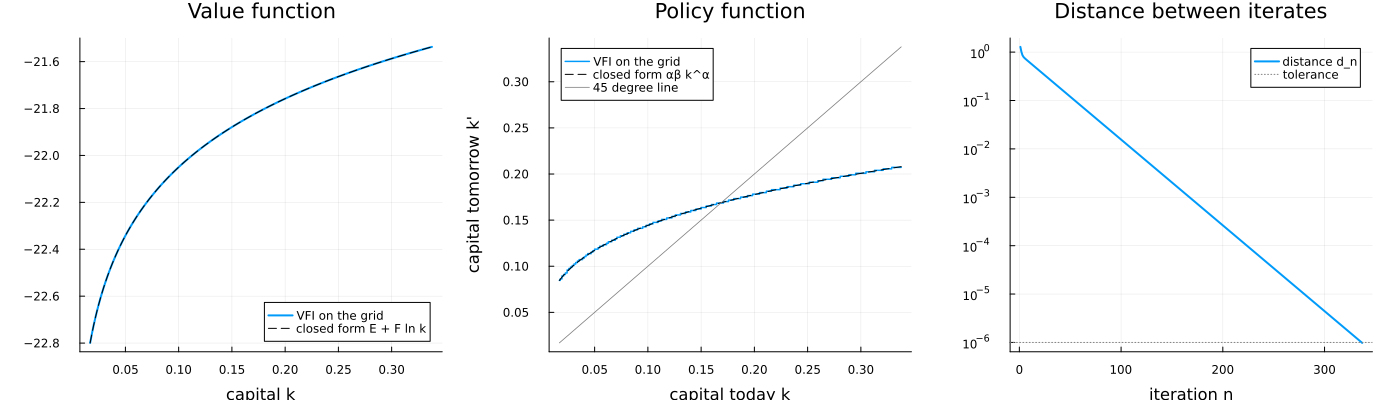

In [17]:
p1 = plot(gri.k, v, linewidth = 2, label = "VFI on the grid", legend = :bottomright,
          xlabel = "capital k", title = "Value function")
plot!(p1, gri.k, v_true, color = :black, linestyle = :dash, label = "closed form E + F ln k")

p2 = plot(gri.k, kprime, seriestype = :stepmid, linewidth = 1.5, label = "VFI on the grid", legend = :topleft,
          xlabel = "capital today k", ylabel = "capital tomorrow k'", title = "Policy function")
plot!(p2, gri.k, kprime_true, color = :black, linestyle = :dash, label = "closed form αβ k^α")
plot!(p2, gri.k, gri.k, color = :gray, linewidth = 0.8, label = "45 degree line")

p3 = plot(1:iterVF, distVF[2:end], yaxis = :log10, linewidth = 2, label = "distance d_n",
          xlabel = "iteration n", title = "Distance between iterates")
hline!(p3, [mpar.crit], color = :gray, linestyle = :dot, label = "tolerance")

plot(p1, p2, p3, layout = (1, 3), size = (1400, 400), margin = 5Plots.mm)

### 6. Experiment: the grid is a modelling choice

Change one field of `mpar` at a time in the cell below, then rerun sections 2
to 5, and note what happens to the policy error, the iteration count, and the
boundary check.

| Try | Question |
| --- | --- |
| `mpar = NumericalParameters(nk = 30)`, then `nk = 2000` | fewer points, many points: which errors move? |
| `mpar = NumericalParameters(spacing = :log)` | more points at low $k$: does it help, and where? |
| `mpar = NumericalParameters(kmax_rel = 0.8)` | is the upper bound still large enough? |
| `mpar = NumericalParameters(kmin_rel = 0.5)` | and the lower bound? |
| `mpar = NumericalParameters(crit = 1e-10)` | does a tighter tolerance buy accuracy? |

Questions to answer in your pair:

1. Which of the three errors (policy, value, distance) responds to $N$, which to $\varepsilon$?
2. Does log spacing help here? Where along the grid does it help, where does it hurt?
3. What does the boundary check say when `kmax_rel` is $0.8$, and why is the result then unusable?
4. How does the iteration count depend on the grid? On $\beta$? Try $\beta = 0.99$.

### 6. Solutions to the experiments

The cell below wraps sections 2 to 5 in one function and runs the six experiments of the table, plus $\beta = 0.99$ from question 4. Every run reports the four numbers you were asked to write down. The figure is the one from the debrief slide: the policy error at every grid point, equidistant against log spaced.

run              iterations  policy error  value error  at a bound
default                 337       9.4e-04      2.4e-05           0
nk = 30                 337       5.6e-03      1.8e-03           0
nk = 2000               337       1.0e-04      2.3e-05           0
spacing = log           337       1.5e-03      2.2e-05           0
kmax_rel = 0.8          337       2.3e-02      1.6e-01          74
kmin_rel = 0.5          337       7.4e-04      5.7e-06           0
crit = 1e-10            563       9.4e-04      4.8e-05           0
β = 0.99               1363       9.8e-04      2.2e-05           0


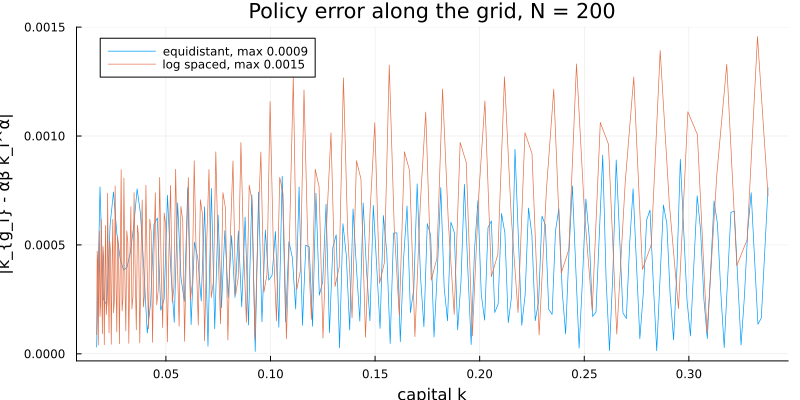

In [18]:
function solve_vfi(par, mpar)
    # sections 2 to 5 in one function, so that the experiments can be run in a loop
    kstar = (par.α * par.β)^(1 / (1 - par.α))
    kmin, kmax = mpar.kmin_rel * kstar, mpar.kmax_rel * kstar
    k = mpar.spacing == :linear ? collect(range(kmin, kmax, length = mpar.nk)) :
                                  exp.(range(log(kmin), log(kmax), length = mpar.nk))
    C = (k .^ par.α) .- k'                   # k_i^α in row i minus k'_j in column j
    U = fill(-Inf, size(C))
    U[C .> 0] = util.(C[C .> 0])
    v, g, distVF, iterVF = zeros(mpar.nk), ones(Int, mpar.nk), [Inf], 0
    while distVF[end] > mpar.crit && iterVF < mpar.maxiter
        M = U .+ par.β .* v'
        vals, idx = findmax(M, dims = 2)
        vnew = vec(vals)
        g    = vec(getindex.(idx, 2))
        push!(distVF, maximum(abs.(vnew .- v)))
        v = vnew
        iterVF += 1
    end
    F = par.α / (1 - par.α * par.β)
    E = (log(1 - par.α * par.β) + par.β * F * log(par.α * par.β)) / (1 - par.β)
    err = abs.(k[g] .- par.α * par.β .* k .^ par.α)
    return (k = k, err = err, iterations = iterVF, policy_error = maximum(err),
            value_error = maximum(abs.(v .- (E .+ F .* log.(k)))),
            at_bounds = count(g .== 1) + count(g .== mpar.nk))
end

experiments = [
    ("default",        EconomicParameters(),         NumericalParameters()),
    ("nk = 30",        EconomicParameters(),         NumericalParameters(nk = 30)),
    ("nk = 2000",      EconomicParameters(),         NumericalParameters(nk = 2000)),
    ("spacing = log",  EconomicParameters(),         NumericalParameters(spacing = :log)),
    ("kmax_rel = 0.8", EconomicParameters(),         NumericalParameters(kmax_rel = 0.8)),
    ("kmin_rel = 0.5", EconomicParameters(),         NumericalParameters(kmin_rel = 0.5)),
    ("crit = 1e-10",   EconomicParameters(),         NumericalParameters(crit = 1e-10)),
    ("β = 0.99",       EconomicParameters(β = 0.99), NumericalParameters()),
]

@printf("%-16s %10s %13s %12s %11s\n", "run", "iterations", "policy error", "value error", "at a bound")
results = Dict{String, Any}()
for (label, p, m) in experiments
    r = solve_vfi(p, m)
    results[label] = r
    @printf("%-16s %10d %13.1e %12.1e %11d\n", label, r.iterations, r.policy_error, r.value_error, r.at_bounds)
end

# the policy error along the grid, equidistant against log spaced (the figure of the debrief slide)
lin, lg = results["default"], results["spacing = log"]
plot(lin.k, lin.err, linewidth = 0.7, label = @sprintf("equidistant, max %.4f", lin.policy_error), legend = :topleft,
     xlabel = "capital k", ylabel = "|k_{g_i} - αβ k_i^α|", title = "Policy error along the grid, N = 200", size = (800, 400))
plot!(lg.k, lg.err, linewidth = 0.7, label = @sprintf("log spaced, max %.4f", lg.policy_error))

**What you should have found**

| run | iterations | policy error | value error | states at a bound |
| --- | ---: | ---: | ---: | ---: |
| default ($N = 200$, $\varepsilon = 10^{-6}$) | 337 | 9.4e-4 | 2.4e-5 | 0 |
| `nk = 30` | 337 | 5.6e-3 | 1.8e-3 | 0 |
| `nk = 2000` | 337 | 1.0e-4 | 2.3e-5 | 0 |
| `spacing = log` | 337 | 1.5e-3 | 2.2e-5 | 0 |
| `kmax_rel = 0.8` | 337 | 2.3e-2 | 1.6e-1 | 74 |
| `kmin_rel = 0.5` | 337 | 7.4e-4 | 5.7e-6 | 0 |
| `crit = 1e-10` | 563 | 9.4e-4 | 4.8e-5 | 0 |
| $\beta = 0.99$ | 1363 | 9.8e-4 | 2.2e-5 | 0 |

**1. Which error responds to $N$, which to $\varepsilon$?** The policy and the value error respond to $N$: from $N = 30$ to $N = 2000$ the policy error falls from 0.0056 to 0.0001, in step with the grid spacing, and the value error from 0.0018 to 0.00002. The distance $d_n$ is the only thing that responds to $\varepsilon$. Tightening $\varepsilon$ from $10^{-6}$ to $10^{-10}$ leaves the policy error at 0.00094: once $\mathbf{v}_n$ is closer to $\mathbf{v}_{\mathcal{K}}$ than $\mathbf{v}_{\mathcal{K}}$ is to $v$, a tighter tolerance buys nothing. The value error even doubles, from 2.4e-5 to 4.8e-5. The iterates approach $\mathbf{v}_{\mathcal{K}}$ from above (we start at $\mathbf{v}_0 = 0$), while $\mathbf{v}_{\mathcal{K}}$ lies below $v$ (the household may only choose grid points), so at $\varepsilon = 10^{-6}$ the remaining stopping error partly cancels the discretization error. At $\varepsilon = 10^{-10}$ the stopping error is gone and the pure discretization error of the value, 4.8e-5, is what remains. Two error sources, and they can have opposite signs.

**2. Does log spacing help?** Not here: the maximum policy error rises from 0.0009 to 0.0015. The error at state $k_i$ is set by the grid spacing at the *chosen* point $k'_i = \alpha\beta k_i^\alpha$, not at $k_i$. Every choice lands in $[0.5\,k^*, 1.23\,k^*]$, since even the poorest state $0.1\,k^*$ saves $0.1^{0.3} k^* \approx 0.5\,k^*$. The dense low end of the log grid is therefore never chosen, while above $0.63\,k^*$ the log grid is coarser than the equidistant one (spacing $k \ln 20 / 199$ against $1.9\,k^* / 199$). In the figure the log error is lower only for the states below about $0.15\,k^*$, whose choices land near $0.55\,k^*$, and higher everywhere else. Log spacing pays when the policy bends sharply at the lower bound of the grid, which is what a binding borrowing limit does in the consumption-savings problem of the coming weeks.

**3. `kmax_rel = 0.8`.** The boundary check reports 74 of 200 states with the policy on $k_N$: the household would like to save more than the grid allows, and the loop silently imposes $k' \leq 0.8\,k^*$ as an extra constraint. The value error is 0.16 instead of 0.00002. Nothing else warns you: 337 iterations, last ratio 0.96, converged as usual. That is why the boundary check is printed in every run. `kmin_rel = 0.5` is harmless, because the policy of every state on the grid lies above $0.5\,k^*$, so the lower end is never chosen. With a borrowing limit this changes: there the policy *will* sit on the lowest grid point for poor households, and that is economics, not a grid that is too small.

**4. The iteration count.** 337 for every grid, whatever $N$ and whatever the spacing, and 563 with $\varepsilon = 10^{-10}$. The rule of thumb $n \approx \ln(\varepsilon / d_1) / \ln \beta$ gives 345 and 570. With $\beta = 0.99$ the count is 1363, about four times as many, and the certificate factor $\beta / (1 - \beta)$ rises from 24 to 99. The count depends on $\beta$ and $\varepsilon$, never on $N$. What $N$ changes is the cost per iteration, the $N^2$ entries of $\mathbf{M}$.